# **ML - Stochastic Gradient Descent (SGD)**

Stochastic Gradient Descent (SGD) is an optimization algorithm in machine learning, particularly when dealing with large datasets. It is a variant of the traditional gradient descent algorithm but offers several advantages in terms of efficiency and scalability making it the go-to method for many deep-learning tasks.

## Working of Stochastic Gradient Descent

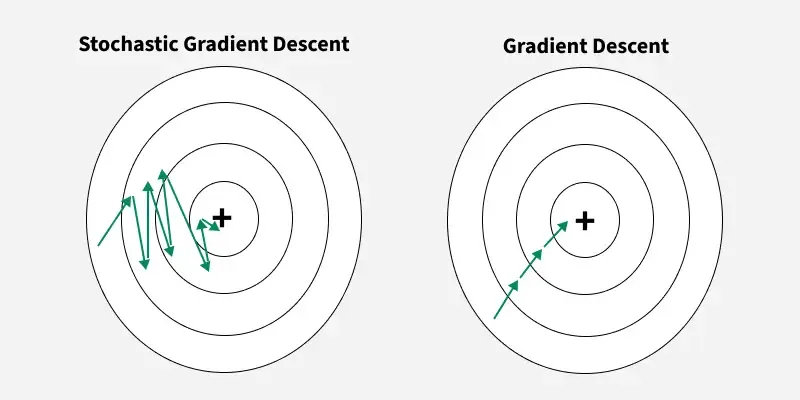

* In traditional gradient descent, the gradients are computed based on the entire dataset which can be computationally expensive for large datasets.
* In Stochastic Gradient Descent, the gradient is calculated for each training example (or a small subset of training examples) rather than the entire dataset.

Stochastic Gradient Descent update rule is:

θ = θ - α * ∇J(θ; x(i); y(i))

Where:
- `θ` represents the parameters (weights) of the model.
- `α` is the learning rate, which controls the step size of the update.
- `∇J(θ; x(i); y(i))` is the gradient of the loss function with respect to the parameters `θ` for a single training example `(x(i), y(i))`.

## Implementing Stochastic Gradient Descent from Scratch

### 1. Generating the Data

* X is a random array of 100 samples between 0 and 2.
* y is the target, calculated using a linear equation with a little random noise to make it more realistic.


In [4]:
import numpy as np

np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

### 2. Defining the SGD Function

* theta (θ) is the parameter vector (intercept and slope) initialized randomly.
* X_bias is the augmented X with a column of ones added for the bias term (intercept).

In [5]:
def sgd(X, y, learning_rate=0.1, epochs=1000, batch_size=1):
    m = len(X)
    theta = np.random.randn(2, 1)

    X_bias = np.c_[np.ones((m, 1)), X]

    cost_history = []

    for epoch in range(epochs):
        indices = np.random.permutation(m)
        X_shuffled = X_bias[indices]
        y_shuffled = y[indices]

        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i:i + batch_size]
            y_batch = y_shuffled[i:i + batch_size]

            gradients = 2 / batch_size * \
                X_batch.T.dot(X_batch.dot(theta) - y_batch)
            theta -= learning_rate * gradients

        predictions = X_bias.dot(theta)
        cost = np.mean((predictions - y) ** 2)
        cost_history.append(cost)

        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Cost: {cost}")

    return theta, cost_history

## 3: Train the Model Using SGD

In [6]:
theta_final, cost_history = sgd(X, y, learning_rate=0.1, epochs=1000, batch_size=1)

Epoch 0, Cost: 1.581821686856939
Epoch 100, Cost: 1.5664692700155742
Epoch 200, Cost: 1.4445422391173137
Epoch 300, Cost: 1.7037674963102662
Epoch 400, Cost: 0.9101999515899212
Epoch 500, Cost: 0.8184497904316664
Epoch 600, Cost: 0.8352333304446239
Epoch 700, Cost: 0.8542729530055074
Epoch 800, Cost: 1.050831031868764
Epoch 900, Cost: 0.8261971232182218


### 4. Visualizing the Cost Function

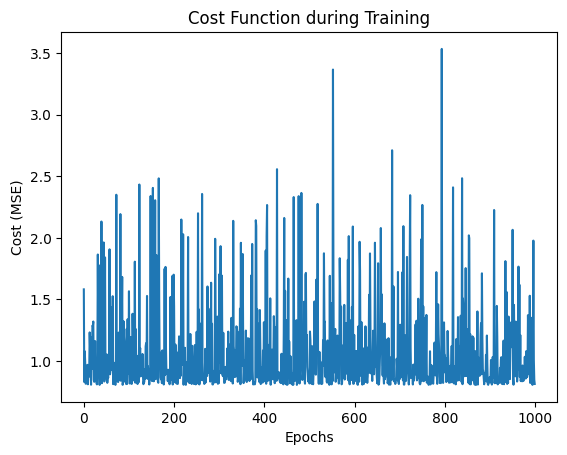

In [7]:
import matplotlib.pyplot as plt

plt.plot(cost_history)
plt.xlabel('Epochs')
plt.ylabel('Cost (MSE)')
plt.title('Cost Function during Training')
plt.show()

### 5. Plotting the Data and Regression Line

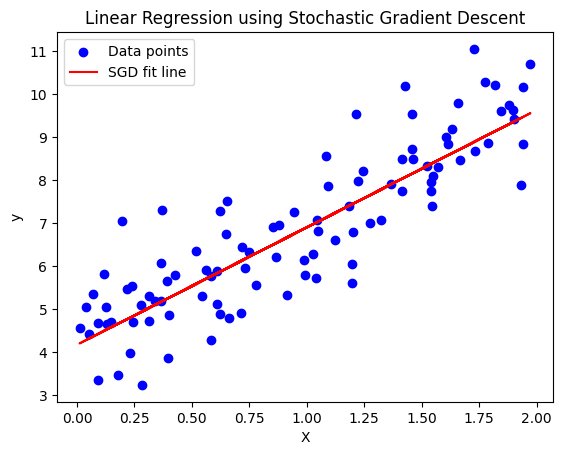

In [8]:
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, np.c_[np.ones((X.shape[0], 1)), X].dot(
    theta_final), color='red', label='SGD fit line')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression using Stochastic Gradient Descent')
plt.legend()
plt.show()

### 6. Printing the Final Model Parameters

In [9]:
print(f"Final parameters: {theta_final}")

Final parameters: [[4.17209292]
 [2.72564644]]


theta1 = 4.17
theta2 = 2.72

y = theta1 + theta2 * X

## Challenges

* **Convergence**: SGD can be noisy and may not converge to the global minimum, especially if the learning rate is not chosen carefully.
* **Learning Rate**: Choosing an appropriate learning rate is crucial. Too high can lead to divergence, while too low can result in slow convergence.
* **Local Minima**: SGD can get stuck in local minima, especially in non-convex optimization problems.

                                                          Mini-Batch Gradient Descent in Deep Learning                        
                                              

## Mini-Batch Gradient Descent in Deep Learning


Mini-batch gradient descent is a variant of the traditional gradient descent algorithm used to optimize the parameters i.e weights and biases of a neural network. It divides the training data into small subsets called mini-batches allowing the model to update its parameters more frequently compared to using the entire dataset at once.

The update rule for Mini-Batch Gradient Descent is:

θ = θ - α * ∇J(θ; X_batch; y_batch)

Where:
- `θ` represents the parameters (weights) of the model.
- `α` is the learning rate.
- `∇J(θ; X_batch; y_batch)` is the gradient of the loss function with respect to the parameters `θ` for a mini-batch of training examples `(X_batch, y_batch)`.

Instead of updating weights after calculating the error for each data point (in stochastic gradient descent) or after the entire dataset (in batch gradient descent), mini-batch gradient descent updates the model’s parameters after processing a mini-batch of data. This provides a balance between computational efficiency and convergence stability.

## Why to use Mini-Batch Gradient Descent?

1. **Faster Convergence**: Mini-batch gradient descent can converge faster than batch gradient descent because it updates the model parameters more frequently, allowing it to make progress towards the minimum of the loss function more quickly.

2. **Reduced Memory Usage**: By processing smaller batches of data, mini-batch gradient descent can be more memory efficient than batch gradient descent, which requires loading the entire dataset into memory.

3. **Better Generalization**: The noise introduced by using mini-batches can help the model escape local minima and potentially find better solutions, leading to improved generalization on unseen data.

## How Mini-Batch Gradient Descent Works

* **Splitting the Data:** The training dataset is divided into smaller mini-batches. Each mini-batch contains a subset of data points. For example if the dataset has 10,000 examples we might split it into 100 mini-batches each containing 100 data points.
* **Computing the Gradient:** For each mini-batch the gradient of the loss function is computed and used to update the model’s parameters. The loss is averaged over the mini-batch which helps in reducing the noise compared to the SGD approach.
* **Updating the Parameters:** Once the gradient is computed for a mini-batch the model’s parameters are updated using the learning rate and the gradient. This step is repeated for each mini-batch and the process continues until all mini-batches have been processed.
* **Epochs:** An epoch refers to one complete pass through the entire dataset. After each epoch the mini-batches are typically reshuffled to ensure that the model does not overfit to the specific order of the data.

## Optimizing Mini-Batch Gradient Descent

* **Learning Rate Schedulers**: Dynamic adjustment of the learning rate during training can improve the performance of mini-batch gradient descent by helping the model converge more smoothly.
* **Momentum**: Using momentum with mini-batch gradient descent can accelerate convergence by helping the model overcome oscillations and reach the global minimum faster.
* **Adam Optimizer**: Adam optimizer combines the benefits of both momentum and RMSProp optimizers and is widely used with mini-batch gradient descent for faster and more reliable convergence.

## 1. Implementing Mini Batch Gradient Descent in TensorFlow

C:\Users\PANDIT JI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4650 - loss: 0.7051
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5080 - loss: 0.6972
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5140 - loss: 0.6959
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5110 - loss: 0.6947
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5100 - loss: 0.6918
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5140 - loss: 0.6895
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5220 - loss: 0.6882
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5300 - loss: 0.6878
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5360 - loss: 0.6858
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5440 - loss: 0.6848


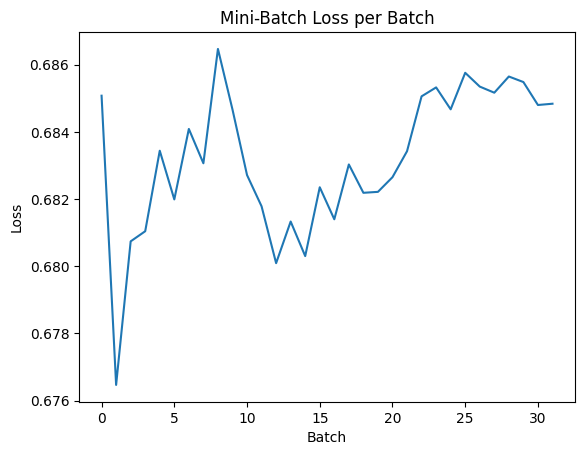

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

X_train = np.random.rand(1000, 20)
y_train = np.random.randint(0, 2, size=(1000, 1))

model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(20,)),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

class BatchLossHistory(tf.keras.callbacks.Callback):
    def on_train_batch_end(self, batch, logs=None):
        self.losses.append(logs['loss'])

    def on_epoch_begin(self, epoch, logs=None):
        self.losses = []

batch_loss_history = BatchLossHistory()

history = model.fit(X_train, y_train, epochs=10, batch_size=32, callbacks=[batch_loss_history], verbose=1)

plt.plot(batch_loss_history.losses)
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.title('Mini-Batch Loss per Batch')
plt.show()

## 2. Implementing Mini Batch Gradient Descent in PyTorch

Epoch [1/10], Loss: 0.7007
Epoch [2/10], Loss: 0.7083
Epoch [3/10], Loss: 0.6462
Epoch [4/10], Loss: 0.6820
Epoch [5/10], Loss: 0.6405
Epoch [6/10], Loss: 0.7248
Epoch [7/10], Loss: 0.6274
Epoch [8/10], Loss: 0.6047
Epoch [9/10], Loss: 0.7710
Epoch [10/10], Loss: 0.5944


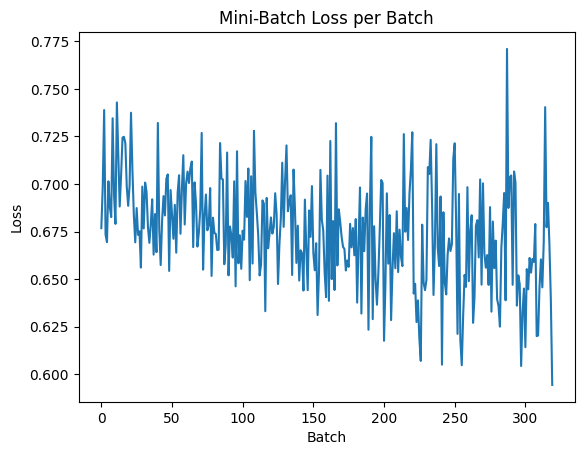

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

X_train = torch.randn(1000, 20)
y_train = torch.randint(0, 2, (1000, 1)).float()

class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(20, 64)
        self.fc2 = nn.Linear(64, 1)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

model = SimpleNN()

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

batch_losses = []
epochs = 10

for epoch in range(epochs):
    for batch_X, batch_y in train_loader:
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        batch_losses.append(loss.item())
    
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

plt.plot(batch_losses)
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.title('Mini-Batch Loss per Batch')
plt.show()